In [1]:
import pandas as pd
import matplotlib
import sqlite3

connection=sqlite3.connect('../data/checking-logs.sqlite')

In [64]:
query = """
SELECT 
    DATE(timestamp) AS date,
    CASE 
        WHEN CAST(strftime('%H', timestamp) AS INTEGER) BETWEEN 4 AND 9 THEN 'morning'
        WHEN CAST(strftime('%H', timestamp) AS INTEGER) BETWEEN 10 AND 16 THEN 'afternoon'
        WHEN CAST(strftime('%H', timestamp) AS INTEGER) BETWEEN 17 AND 23 THEN 'evening'
        ELSE 'night'
    END AS daytime,
    COUNT(*) AS commits_count
FROM checker 
WHERE uid LIKE 'user_%' 
GROUP BY DATE(timestamp), daytime
ORDER BY date
"""

df = pd.read_sql_query(query, connection)
df

,date,daytime,commits_count
0,2020-04-17,afternoon,10
1,2020-04-17,morning,13
2,2020-04-18,afternoon,33
3,2020-04-18,evening,35
4,2020-04-18,morning,1
...,...,...,...
85,2020-05-20,evening,10
86,2020-05-20,morning,7
87,2020-05-21,afternoon,27
88,2020-05-21,evening,21


In [72]:
df=pd.read_sql(sql='''SELECT date(timestamp) as date, strftime('%H' , timestamp) as hour , COUNT(*) as count FROM checker WHERE uid LIKE 'user_%' GROUP BY date, hour
               ''', con=connection)
df

,date,hour,count
0,2020-04-17,05,13
1,2020-04-17,11,8
2,2020-04-17,12,2
3,2020-04-18,07,1
4,2020-04-18,13,5
...,...,...,...
283,2020-05-21,16,4
284,2020-05-21,17,1
285,2020-05-21,18,2
286,2020-05-21,19,8


In [73]:
df['hour']=df['hour'].astype(int)
time_bins = [-1, 3, 9,16,23]
time_labels = ["night", "morning", "afternoon", "evening"]
df["daytime"] = pd.cut(df["hour"], bins=time_bins, labels=time_labels)
df

,date,hour,count,daytime
0,2020-04-17,5,13,morning
1,2020-04-17,11,8,afternoon
2,2020-04-17,12,2,afternoon
3,2020-04-18,7,1,morning
4,2020-04-18,13,5,afternoon
...,...,...,...,...
283,2020-05-21,16,4,afternoon
284,2020-05-21,17,1,evening
285,2020-05-21,18,2,evening
286,2020-05-21,19,8,evening


In [80]:
pivot_data = df.pivot_table(index='date', columns='daytime', values='count', aggfunc='sum')
pivot_data

C:\Users\sofia\AppData\Local\Temp\ipykernel_16216\3515634868.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df.pivot_table(index='date', columns='daytime', values='count', aggfunc='sum')


daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
2020-04-22,0,0,4,24
2020-04-23,2,6,15,20
2020-04-24,0,0,4,12
2020-04-25,1,21,33,49


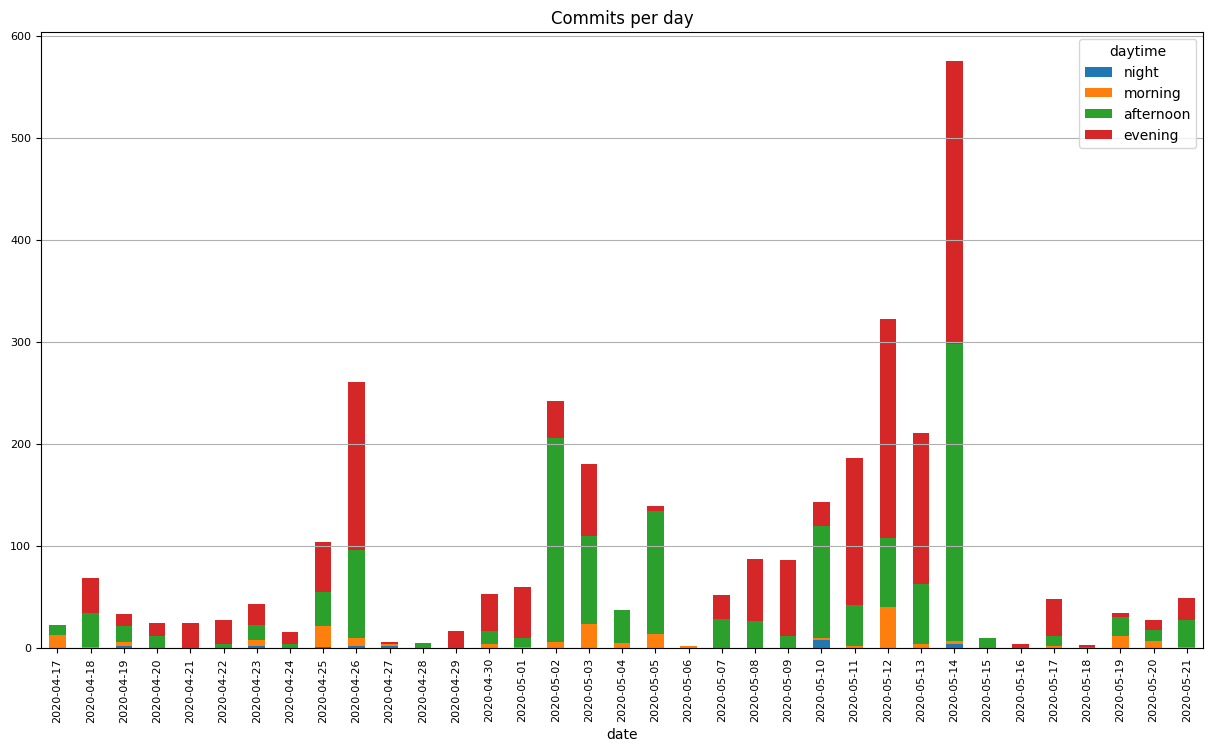

In [62]:
graph=pivot_data.plot(kind='bar',stacked=True,figsize=(15,8), fontsize=8,title='Commits per day')
graph.yaxis.grid(True)

In [82]:
pivot_data[pivot_data['evening'] > pivot_data['afternoon']].sum(axis=1).idxmax()

'2020-05-12'

In [87]:
pivot_data.sum()

daytime
night          21
morning       184
afternoon    1391
evening      1611
dtype: int64

In [84]:
df['daytime'].value_counts()

daytime
evening      124
afternoon    116
morning       40
night          8
Name: count, dtype: int64

In [ ]:
connection.close()

When do our users usually commit to the labs: in the night, morning, afternoon, or evening? The answer is the two most common periods.

Evening and afternoon

Which day has:  
the most number of commits? **2020-05-14**  
and at the same time, is the number of commits higher in the evening than in the afternoon? **2020-05-12**